# Chapter 5. What goes on the report by channel that Anand signs, and does its gap column tell the truth?

**Week 2, Tuesday · Chapter 5 of 6 · Booked against collected.**

> **The client asks.** "Booked revenue is not collected revenue. Some orders are paid in two
> instalments, some are refunded, some were never paid at all. Show me, order by order, what we
> actually collected against what we booked in Q2. If there is a gap, I want to know which orders
> and which channel."
>
> Anand Iyer, finance controller, Kalpa Retail

The data platform lead added the payments table to the team's access and said, in passing, that
the payments feed "sometimes double-posts when the gateway retries".

**Who needs the answer.** Anand, who signs the report and sends it on to the CEO's Monday page, and the channel heads, who chase their own unpaid orders from it. A gap column that reads zero stands every one of them down, and a report that does not add back to the bridge cannot be defended when Anand's analyst audits it.

**The questions on the way.**
1. What must a line per channel carry for Anand to sign it?
2. Which of four report forms fits a finance controller?
3. What does the gap column say when each order's gap is added up?
4. Why is it wrong, and which check catches it?
5. Does the fixed report add back to the bridge on Kalpa's Q2?
6. Does the unpaid list, grouped by channel, give the same gap?

**The metric at stake.** Booked, collected and the gap between them, by channel: app, store and web. The gap is booked less collected, order by order, and it must add up to the bridge's never-paid and paid-short bars.

**What came before, and what this adds.** Chapter 4 put names behind the bridge. On the invented tables the unpaid list is T-4, 800, and the double-paid list is T-3's instalment 1 posted twice, 1,500; on Kalpa's Q2 you built both lists and each matched its bar, and every one of the 1,428 payment rows was accounted for. This chapter turns all of it into the page Anand signs.

**Setup.** The next cell finds the helper, connects to the warehouse and creates the invented tables
of chapter 1. Every query below is also in `sql/C2_W02_D02_05_what_anand_signs_STUDENT.sql`.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit
from decimal import Decimal

TINY = """DROP TABLE IF EXISTS tiny_orders, tiny_payments;
CREATE TEMP TABLE tiny_orders (
    order_id  text PRIMARY KEY,
    channel   text NOT NULL,
    amount    numeric(12, 2) NOT NULL
);
CREATE TEMP TABLE tiny_payments (
    payment_id    text PRIMARY KEY,
    order_id      text NOT NULL,
    paid_date     date NOT NULL,
    amount        numeric(12, 2) NOT NULL,
    instalment_no integer NOT NULL
);
INSERT INTO tiny_orders VALUES
    ('T-1', 'app',   1000),
    ('T-2', 'web',   2000),
    ('T-3', 'store', 1500),
    ('T-4', 'app',    800),
    ('T-5', 'store',  500);
INSERT INTO tiny_payments VALUES
    ('P-1', 'T-1', '2026-07-03', 1000, 1),
    ('P-2', 'T-2', '2026-07-05', 1200, 1),
    ('P-3', 'T-2', '2026-08-05',  800, 2),
    ('P-4', 'T-3', '2026-07-09', 1500, 1),
    ('P-5', 'T-3', '2026-07-09', 1500, 1),
    ('P-6', 'T-5', '2026-07-12',  500, 1),
    ('P-7', 'T-9', '2026-07-14',  600, 1);"""

conn = kit.connect()
conn.autocommit = True
with conn.cursor() as cur:
    cur.execute(TINY)            # invented, TEMP, so they vanish when this notebook stops


def run(query, params=None):
    """Run a query on this notebook's one connection and return its rows as dictionaries."""
    return kit.sql(query, params, conn=conn)


def one(query, params=None):
    """The first value of the first row, for a query that returns a single number."""
    row = run(query, params)[0]
    return next(iter(row.values()))


def show(rows, caption="", money=()):
    """Rows as the kit's table; columns named in money print as rupees."""
    if not rows:
        return kit.table(["result"], [["no rows"]], caption)
    heads = list(rows[0])
    body = []
    for r in rows:
        line = []
        for h in heads:
            v = r[h]
            if v is None:
                line.append("NULL")
            elif h in money:
                line.append(kit.rupees(v))
            elif isinstance(v, Decimal):
                line.append(f"{int(v):,}" if v == v.to_integral_value() else f"{float(v):,.2f}")
            else:
                line.append(str(v))
        body.append(line)
    kit.table(heads, body, caption)

kb = {k: (v or 0) for k, v in run("""WITH per_order AS (
WITH per_instalment AS (
    SELECT order_id, instalment_no, max(amount) AS amount
    FROM payments
    GROUP BY order_id, instalment_no
),
collected_per_order AS (
    SELECT order_id, sum(amount) AS collected
    FROM per_instalment
    GROUP BY order_id
),
posted_per_order AS (
    SELECT order_id, sum(amount) AS posted
    FROM payments
    GROUP BY order_id
)
SELECT o.order_id, o.channel, o.amount AS booked, c.collected, p.posted
FROM orders o
LEFT JOIN collected_per_order c ON c.order_id = o.order_id
LEFT JOIN posted_per_order p    ON p.order_id = o.order_id
WHERE o.quarter = 'Q2'
)
SELECT sum(booked)                                                    AS booked,
       sum(booked) FILTER (WHERE collected IS NULL)                   AS never_paid,
       sum(booked - collected) FILTER (WHERE collected < booked)      AS paid_short,
       sum(collected)                                                 AS collected,
       sum(posted - collected)                                        AS posted_twice,
       sum(posted)                                                    AS posted
FROM per_order""")[0].items()}
booked_ch = run("""
SELECT channel, count(*) AS orders, sum(amount) AS booked
FROM orders
WHERE quarter = 'Q2'
GROUP BY channel
ORDER BY channel""")
print("Kalpa's Q2 booked by channel, from orders alone:",
      ", ".join(f'{r["channel"]} {kit.rupees(r["booked"])}' for r in booked_ch))

Kalpa's Q2 booked by channel, from orders alone: app Rs 4,25,90,270, store Rs 3,21,48,730, web Rs 2,36,61,000


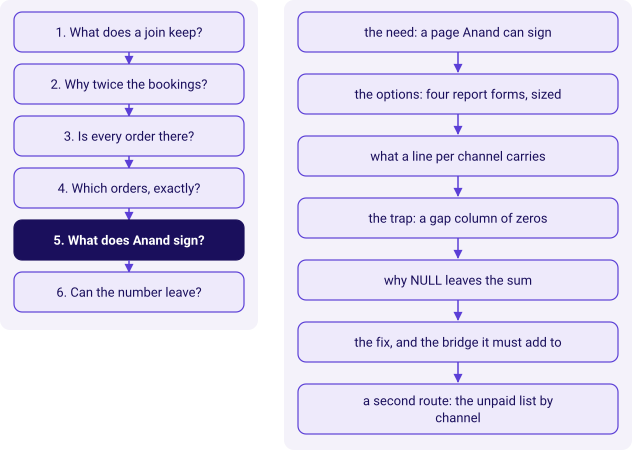

In [2]:
kit.side_by_side(
    kit.ladder(['What does a join keep?', 'Why twice the bookings?', 'Is every order there?', 'Which orders, exactly?', 'What does Anand sign?', 'Can the number leave?'], lit=4, show=False),
    kit.vflow(['the need: a page Anand can sign', 'the options: four report forms, sized', 'what a line per channel carries', 'the trap: a gap column of zeros', 'why NULL leaves the sum', 'the fix, and the bridge it must add to', 'a second route: the unpaid list by channel'], show=False),
)

## What does Anand need on the page before he signs it?

Anand signs the report and it goes on to Meera Raghavan's Monday page, so every figure on it becomes
his figure. He needs the gap split by channel, because the store team, the app team and the web team
each chase their own customers; he needs the orders behind the gap, because a channel total cannot
be chased; and he needs the proof above the number, because his analyst will audit it. A report
that says nothing is outstanding closes the question for everyone who reads it. The retail story behind Anand's role, how a sale becomes cash and who checks it, is in the domain dossier, `content/W01/D1/study-notes/C2_W01_D01_domain_retail_STUDENT.md`, sections 3 and 4.

**Who else faces this.** Infosys reports the gap between what it has billed and what it has
collected every quarter, as days sales outstanding, which is money owed by customers divided by
revenue per day: 63 days for the quarter ended 30 June 2026, against 67 at 31 March 2026 and 70 a
year earlier, on the last twelve months' revenue (Infosys fact sheet, filed with the US Securities
and Exchange Commission as Exhibit 99.4 to its Form 6-K, checked 30 Sep 2026). A finance team that
publishes a collections figure every quarter answers for it, which is the position Anand is in when
he signs this report.

**The two invented tables.** Five orders and seven payments, invented to carry every case Anand
named and the one the platform lead mentioned, so every row can be checked by hand:

| order_id | channel | amount | What happened to it |
|---|---|---|---|
| T-1 | app | 1,000 | Paid once, in full (P-1) |
| T-2 | web | 2,000 | Paid in two instalments, 1,200 and 800 (P-2, P-3) |
| T-3 | store | 1,500 | Paid once, and the gateway posted that payment twice (P-4, P-5) |
| T-4 | app | 800 | Never paid |
| T-5 | store | 500 | Paid once, in full (P-6) |

P-7 is a payment of 600 against T-9, an order that is not in the orders table.

## Which of four report forms fits a finance controller, and what does each cost?

| Option | What Anand reads | What he can act on | What he can audit |
|---|---|---|---|
| A. One number: the total gap | 1 line | Nothing: no channel, no order | Nothing |
| B. A table by channel | 3 channels and a total | Which channel to chase | The totals, against booked |
| C. The table by channel, with the reconciliation above it and the two lists beneath | The table, 4 reconciliation lines, 2 lists | Which channel, and which orders | Every figure, back to the bridge |
| D. The whole statement, one line per order | 462 lines on Kalpa's Q2 | Anything, once found | Everything, if read |

The cell below sizes each form on Kalpa's Q2 by what it asks of the reader.

Form,"Lines Anand reads, before any list",He can act on,He can audit
A. one number,1,none,none
B. by channel,4,channel,totals
"C. by channel, reconciled, with lists",8,channel and order,every figure
D. the whole statement,462,"order, once found",every line


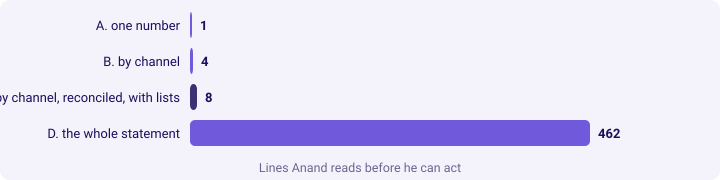

In [3]:
orders_q2 = sum(r["orders"] for r in booked_ch)
forms = [("A. one number", 1, "none", "none"), ("B. by channel", len(booked_ch) + 1, "channel", "totals"),
         ("C. by channel, reconciled, with lists", len(booked_ch) + 1 + 4, "channel and order", "every figure"),
         ("D. the whole statement", orders_q2, "order, once found", "every line")]
kit.table(["Form", "Lines Anand reads, before any list", "He can act on", "He can audit"], forms,
          caption="Four report forms, sized on Kalpa's Q2")
kit.bars([(f[0], f[1]) for f in forms], lit=[2], title="Lines Anand reads before he can act")
kit.check("the statement form asks Anand to read one line per Q2 order", forms[3][1] == 462, f"{orders_q2} lines")

**The best-fit call.** C, the table by channel with the reconciliation written above it and the two
lists beneath. It is the smallest page on which Anand can both act, by channel and by order, and
audit, since every figure ties back to the bridge. A alone hides where the gap sits; B tells the
store team to chase without telling them whom; D answers everything and asks Anand to find it in
462 lines.

**The fact that would change the call.** At the quarter's close, when the auditors ask for evidence
order by order, D travels with the signed page as an appendix file; the page itself stays C.

## 1. What must a line per channel carry for Anand to sign it?

One line per channel: the orders booked, booked, collected, and the gap, with a definition line
above the table, "collected: cash received against Q2 orders, each payment counted once; posted
twice and refunds are shown separately", so no reader has to guess which of the day's numbers this
is. The report is built from chapter 3's table of one row per order, grouped by channel.

**Predict before you run.** On the invented tables, which channel carries booked of 1,800?
a) web; b) store; c) app; d) none, every channel books 2,000.

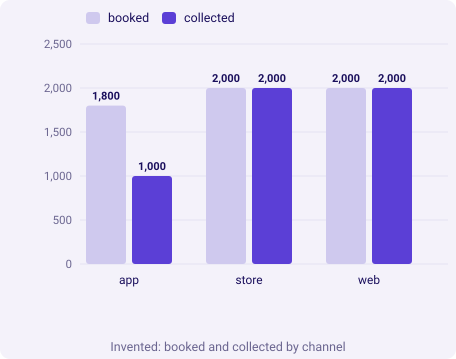

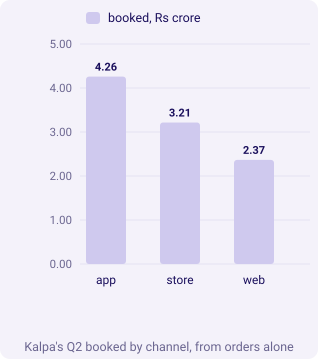

In [4]:
fixed_tiny = run("""WITH per_order AS (
WITH per_instalment AS (
    SELECT order_id, instalment_no, max(amount) AS amount
    FROM tiny_payments
    GROUP BY order_id, instalment_no
),
collected_per_order AS (
    SELECT order_id, sum(amount) AS collected
    FROM per_instalment
    GROUP BY order_id
),
posted_per_order AS (
    SELECT order_id, sum(amount) AS posted
    FROM tiny_payments
    GROUP BY order_id
)
SELECT o.order_id, o.channel, o.amount AS booked, c.collected, p.posted
FROM tiny_orders o
LEFT JOIN collected_per_order c ON c.order_id = o.order_id
LEFT JOIN posted_per_order p    ON p.order_id = o.order_id
)
SELECT channel,
       count(*)                                  AS orders,
       sum(booked)                               AS booked,
       sum(collected)                            AS collected,
       sum(booked - coalesce(collected, 0))                 AS gap
FROM per_order
GROUP BY channel
ORDER BY channel""")
kit.columns([r["channel"] for r in fixed_tiny],
            [("booked", [float(r["booked"]) for r in fixed_tiny]),
             ("collected", [float(r["collected"] or 0) for r in fixed_tiny])],
            fmt=lambda v: f"{v:,.0f}", title="Invented: booked and collected by channel")
kit.columns([r["channel"] for r in booked_ch], [("booked, Rs crore", [float(r["booked"]) / 1e7 for r in booked_ch])],
            fmt=lambda v: f"{v:.2f}", title="Kalpa's Q2 booked by channel, from orders alone")
kit.check("the channels' booked adds to Monday's Rs 9,84,00,000",
          sum(r["booked"] for r in booked_ch) == 98400000, kit.rupees(sum(r["booked"] for r in booked_ch)))

**What happened.** The answer is c: app books 1,800, T-1's 1,000 and T-4's 800, and collects 1,000;
web and store each book 2,000 and collect it. On Kalpa's Q2, app books Rs 4,25,90,270 over 153
orders, store Rs 3,21,48,730 over 159 and web Rs 2,36,61,000 over 150, adding to Monday's
Rs 9,84,00,000.

## 2. What does the gap column say when each order's gap is added up?

**The plausible wrong answer.** Anand asked "order by order", so a teammate computes each order's
gap, booked less collected, and adds the gaps up by channel:

```sql
SELECT channel, count(*) AS orders, sum(booked) AS booked, sum(collected) AS collected,
       sum(booked - collected) AS gap
FROM per_order
GROUP BY channel;
```

**Predict before you run.** On the invented tables, what does the gap column say for app?
a) 800; b) 0; c) NULL; d) 1,800.

channel,orders,booked,collected,gap
app,2,"1,800","1,000",0
store,2,"2,000","2,000",0
web,1,"2,000","2,000",0


Channel,"Gap, as the hurried report states it"
app,Rs 0
store,Rs 0
web,Rs 0


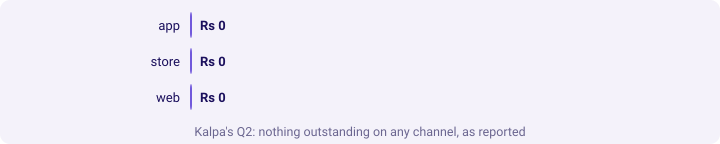

In [5]:
hurried_tiny = run("""WITH per_order AS (
WITH per_instalment AS (
    SELECT order_id, instalment_no, max(amount) AS amount
    FROM tiny_payments
    GROUP BY order_id, instalment_no
),
collected_per_order AS (
    SELECT order_id, sum(amount) AS collected
    FROM per_instalment
    GROUP BY order_id
),
posted_per_order AS (
    SELECT order_id, sum(amount) AS posted
    FROM tiny_payments
    GROUP BY order_id
)
SELECT o.order_id, o.channel, o.amount AS booked, c.collected, p.posted
FROM tiny_orders o
LEFT JOIN collected_per_order c ON c.order_id = o.order_id
LEFT JOIN posted_per_order p    ON p.order_id = o.order_id
)
SELECT channel,
       count(*)                                  AS orders,
       sum(booked)                               AS booked,
       sum(collected)                            AS collected,
       sum(booked - collected)                 AS gap
FROM per_order
GROUP BY channel
ORDER BY channel""")
show(hurried_tiny, "Invented: the gap column, each order's gap added up")
hurried_kalpa = run("""WITH per_order AS (
WITH per_instalment AS (
    SELECT order_id, instalment_no, max(amount) AS amount
    FROM payments
    GROUP BY order_id, instalment_no
),
collected_per_order AS (
    SELECT order_id, sum(amount) AS collected
    FROM per_instalment
    GROUP BY order_id
),
posted_per_order AS (
    SELECT order_id, sum(amount) AS posted
    FROM payments
    GROUP BY order_id
)
SELECT o.order_id, o.channel, o.amount AS booked, c.collected, p.posted
FROM orders o
LEFT JOIN collected_per_order c ON c.order_id = o.order_id
LEFT JOIN posted_per_order p    ON p.order_id = o.order_id
WHERE o.quarter = 'Q2'
)
SELECT channel,
       count(*)                                  AS orders,
       sum(booked)                               AS booked,
       sum(collected)                            AS collected,
       sum(booked - collected)                 AS gap
FROM per_order
GROUP BY channel
ORDER BY channel""")
kit.table(["Channel", "Gap, as the hurried report states it"],
          [(r["channel"], kit.rupees(r["gap"] or 0)) for r in hurried_kalpa],
          caption="Kalpa's Q2: the gap column the teammate would send")
kit.bars([(r["channel"], float(r["gap"] or 0)) for r in hurried_kalpa] or [("none", 0)],
         fmt=lambda v: kit.rupees(v), title="Kalpa's Q2: nothing outstanding on any channel, as reported")

**What happened.** The answer is b: the gap column says 0 for app, and 0 for every channel, on the
invented tables and on Kalpa's Q2 alike. Read as it stands, the report says Kalpa collected every
rupee it booked, on every channel, and Anand signs a page that stands his collections team down.

## 3. Why is it wrong, and which check catches it?

**Why it is wrong.** An order nobody paid has no collected figure: its `collected` is NULL, since the
LEFT JOIN found no payment for it. `booked - NULL` is NULL, not booked, and `sum()` skips NULLs
without saying so, the same way Monday's AVG skipped them. So the unpaid orders, the very orders the
gap exists to show, drop out of the gap, and every paid order at Kalpa was paid in full, so what
remains adds to zero.

**The check that catches it.** The gap column must equal booked less collected computed as two
separate sums, which `sum()` handles correctly because each column is summed on its own; and no
order may reach the report with a NULL gap. On the invented tables the gap column says 0 for app,
two separate sums say 1,800 less 1,000, which is 800, and one order, T-4, carries a NULL gap.

order_id,channel,booked,collected,gap
T-1,app,"1,000","1,000",0
T-2,web,"2,000","2,000",0
T-3,store,"1,500","1,500",0
T-4,app,800,NULL,NULL
T-5,store,500,500,0


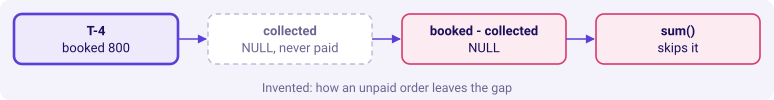

In [6]:
gaps = run("""WITH per_order AS (
WITH per_instalment AS (
    SELECT order_id, instalment_no, max(amount) AS amount
    FROM tiny_payments
    GROUP BY order_id, instalment_no
),
collected_per_order AS (
    SELECT order_id, sum(amount) AS collected
    FROM per_instalment
    GROUP BY order_id
),
posted_per_order AS (
    SELECT order_id, sum(amount) AS posted
    FROM tiny_payments
    GROUP BY order_id
)
SELECT o.order_id, o.channel, o.amount AS booked, c.collected, p.posted
FROM tiny_orders o
LEFT JOIN collected_per_order c ON c.order_id = o.order_id
LEFT JOIN posted_per_order p    ON p.order_id = o.order_id
)
SELECT order_id, channel, booked, collected, booked - collected AS gap
FROM per_order
ORDER BY order_id""")
show(gaps, "Invented: one row per order, where T-4's gap is NULL")
app = next(r for r in hurried_tiny if r["channel"] == "app")
two_sums = app["booked"] - app["collected"]
null_gaps = sum(1 for r in gaps if r["gap"] is None)
kit.flow(["T-4\nbooked 800", "collected\nNULL, never paid", "booked - collected\nNULL", "sum()\nskips it"],
         kinds=["known", "unknown", "bad", "bad"], title="Invented: how an unpaid order leaves the gap")
kit.check("the check catches it: app's gap column disagrees with booked less collected",
          (app["gap"] or 0) != two_sums, f'{int(app["gap"] or 0):,} against {int(two_sums):,}')
kit.check("the check catches it: one invented order reaches the report with a NULL gap", null_gaps == 1, "T-4")

**The fix, and what changed.** `coalesce(collected, 0)` says on purpose that an order with no payment
collected nothing, so its gap is its whole booked amount:

```sql
sum(booked - coalesce(collected, 0)) AS gap
```

On the invented tables app's gap becomes 800, T-4, and every other channel stays at 0. The report now
agrees with the bridge: its gaps add to the never-paid bar, since nothing was paid short.

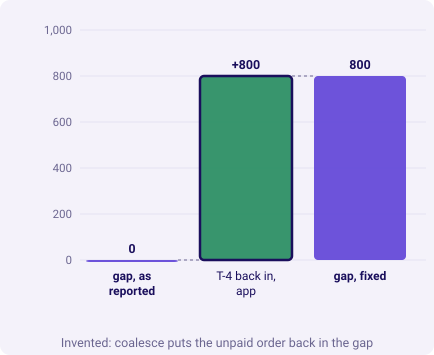

In [7]:
kit.bridge(("gap, as reported", 0.0),
           [("T-4 back in, app", float(next(r["gap"] for r in fixed_tiny if r["channel"] == "app")))],
           end_label="gap, fixed", fmt=lambda v: f"{v:,.0f}", lit=[0],
           title="Invented: coalesce puts the unpaid order back in the gap")
kit.check("the fixed invented report's gaps add to the never-paid bar",
          sum(r["gap"] for r in fixed_tiny) == 800, f'{int(sum(r["gap"] for r in fixed_tiny)):,}')

## 4. Does the fixed report add back to the bridge on Kalpa's Q2?

**Your turn.** Build the page Anand signs. In the empty cell below, type:

```python
page = run(Q_REPORT)
show(page, "Booked against collected, Q2, by channel",
     money=["booked", "collected", "gap", "posted_twice"])
```

`Q_REPORT` adds, beside the gap, the share collected, the orders never paid and the amount posted
twice, per channel. The cell after it defines the query and checks, without printing any figure,
that the page adds back to the bridge from chapter 3.

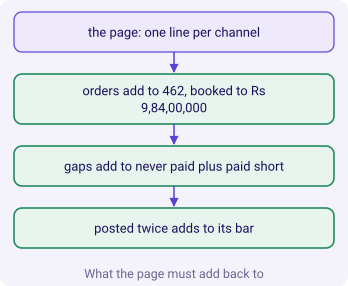

In [8]:
Q_REPORT = """WITH per_order AS (
WITH per_instalment AS (
    SELECT order_id, instalment_no, max(amount) AS amount
    FROM payments
    GROUP BY order_id, instalment_no
),
collected_per_order AS (
    SELECT order_id, sum(amount) AS collected
    FROM per_instalment
    GROUP BY order_id
),
posted_per_order AS (
    SELECT order_id, sum(amount) AS posted
    FROM payments
    GROUP BY order_id
)
SELECT o.order_id, o.channel, o.amount AS booked, c.collected, p.posted
FROM orders o
LEFT JOIN collected_per_order c ON c.order_id = o.order_id
LEFT JOIN posted_per_order p    ON p.order_id = o.order_id
WHERE o.quarter = 'Q2'
)
SELECT channel,
       count(*)                                                AS orders,
       sum(booked)                                             AS booked,
       sum(coalesce(collected, 0))                             AS collected,
       sum(booked - coalesce(collected, 0))                    AS gap,
       round(100 * sum(coalesce(collected, 0)) / sum(booked), 2) AS collected_pct,
       count(*) FILTER (WHERE collected IS NULL)               AS unpaid_orders,
       sum(coalesce(posted, 0) - coalesce(collected, 0))       AS posted_twice
FROM per_order
GROUP BY channel
ORDER BY channel"""
page_rows = run(Q_REPORT)
kit.vflow(["the page: one line per channel", "orders add to 462, booked to Rs 9,84,00,000",
           "gaps add to never paid plus paid short", "posted twice adds to its bar"],
          kinds=["plain", "good", "good", "good"], title="What the page must add back to")
kit.check("the page's orders add to Q2's 462", sum(r["orders"] for r in page_rows) == 462, "462")
kit.check("the page's booked adds to Monday's figure", sum(r["booked"] for r in page_rows) == kb["booked"],
          kit.rupees(kb["booked"]))
kit.check("the page's gaps add to never paid plus paid short",
          sum(r["gap"] for r in page_rows) == kb["never_paid"] + kb["paid_short"], "equal to the rupee")
kit.check("the page's posted twice adds to its bar", sum(r["posted_twice"] for r in page_rows) == kb["posted_twice"],
          "equal to the rupee")

> **Kavya's review.** "Every rupee on the page ties back to a bar, and every bar to a list. Write the
> definition of collected above the table, so nobody reads it as posted."

## Does the unpaid list, grouped by channel, give the same gap?

The second route builds the gap by channel from a different place: chapter 4's unpaid list, written
with NOT EXISTS, grouped by channel. It never computes a per-order gap, so a NULL cannot fall out of
it. Nothing on Kalpa's Q2 was paid short, so the gap by channel must equal the unpaid list by
channel, channel for channel.

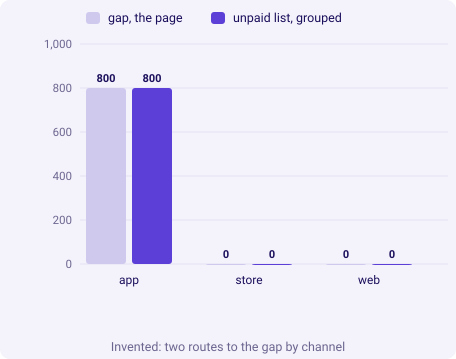

In [9]:
un_tiny = {r["channel"]: r["never_paid"] for r in run("""
SELECT o.channel, sum(o.amount) AS never_paid
FROM tiny_orders o
WHERE NOT EXISTS (SELECT 1 FROM tiny_payments p WHERE p.order_id = o.order_id)
GROUP BY o.channel""")}
kit.columns([r["channel"] for r in fixed_tiny],
            [("gap, the page", [float(r["gap"]) for r in fixed_tiny]),
             ("unpaid list, grouped", [float(un_tiny.get(r["channel"], 0)) for r in fixed_tiny])],
            fmt=lambda v: f"{v:,.0f}", title="Invented: two routes to the gap by channel")
kit.check("invented: the gap by channel equals the unpaid list by channel",
          all(r["gap"] == un_tiny.get(r["channel"], 0) for r in fixed_tiny), "app 800, web 0, store 0")
un_kalpa = {r["channel"]: r["never_paid"] for r in run("""
SELECT o.channel, sum(o.amount) AS never_paid
FROM orders o
WHERE o.quarter = 'Q2'
  AND NOT EXISTS (SELECT 1 FROM payments p WHERE p.order_id = o.order_id)
GROUP BY o.channel""")}
kit.check("Kalpa's Q2: the gap by channel equals the unpaid list by channel, on every channel",
          all(r["gap"] == un_kalpa.get(r["channel"], 0) for r in page_rows), "equal to the rupee, unprinted")
refunds = run("""
SELECT o.quarter, count(*) AS refund_rows
FROM refunds r
JOIN orders o ON o.order_id = r.order_id
GROUP BY o.quarter
ORDER BY o.quarter""")
kit.check("the refunds table holds no refund against a Q2 order", all(r["quarter"] != "Q2" for r in refunds),
          ", ".join(f'{r["quarter"]}: {r["refund_rows"]} rows' for r in refunds))

**What happened.** The two routes agree channel for channel, on the invented tables and on Kalpa's Q2.
The last check answers the one part of Anand's message the report has not touched, refunds: every
refund row in the warehouse sits on a Q1 order, so the Q2 page says so in one line under the table.

**The sentence to Anand.** The page ends on one sentence he can repeat, with the figures you read
from your own page:

> "Q2 booked Rs 9,84,00,000 and collected Rs ___, each payment counted once; the gap of Rs ___ is
> ___ orders nobody has paid, listed by channel, and the largest share sits on the ___ channel. Separately,
> Rs ___ was posted twice by gateway retries and ___ payments match no order; both lists go to the
> platform lead. Every figure ties back to the orders and payments tables."

### [D] Anand says the gap is too small to matter: how do you decide whether to chase it?

Size it before judging it. Split it by channel and by order, since a small total can be one large
invoice; check how old each unpaid order is, since at Kalpa a paid order is paid within days of
being booked, so an unpaid order from July is overdue rather than early; and set the cost of chasing,
a call or a reminder, against the cash each order carries. Then recommend chasing the large and old
ones first, and say what you would drop.

### [F] Why does the page show booked and collected, and not only the gap?

Because the gap cannot be checked on its own. With booked and collected beside it, anyone can
subtract and see the gap is right, and the same subtraction exposes a NULL that fell out of it; a
gap column alone hides exactly the error this chapter staged.

### Depth: why does SQL let NULL fall out of a sum without a warning?

The SQL standard defines aggregate functions such as SUM and AVG to ignore NULLs, so a column with
missing values still sums. The price is that a missing value and a zero look the same in a total.
The defence is to decide, per column, what a NULL means in the business, and to write that decision
into the query with `coalesce`, which Monday met in its NULL trap.

## What did this chapter answer, one line per question?

1. A line per channel carries the orders, booked, collected and the gap, under a definition line; on
   Kalpa's Q2 booked is app Rs 4,25,90,270, store Rs 3,21,48,730 and web Rs 2,36,61,000.
2. The table by channel, reconciled above and with the two lists beneath, fits a finance controller:
   he can act by channel and order and audit every figure.
3. Adding each order's gap reports 0 on every channel, on the invented tables and on Kalpa's Q2.
4. It is wrong because an unpaid order's gap is NULL and `sum()` skips it; the gap column against
   booked less collected as two sums catches it, and `coalesce(collected, 0)` fixes it.
5. The fixed page adds back to the bridge on Kalpa's Q2: 462 orders, Rs 9,84,00,000 booked, the gaps
   and the amount posted twice each equal to their bars.
6. The unpaid list grouped by channel gives the same gap on every channel.

**The question this leaves.** The page is right today. What must pass, every Monday, before the
collected number leaves the team, and what does Anand get when a check fails at the end of
reporting day? That is chapter 6.

In [10]:
kit.check_summary()